# Floor Plans Checking

## Setup
This includes the libraries required, and all of the functions we have made.

### Libraries Required

In [1]:
# Import necessary libraries. I think most are installed by default on typical python installs.
import json
import networkx as nx
from networkx.readwrite import json_graph
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
import os
import pickle
from PIL import Image
import itertools
from tqdm import tqdm
from IPython.display import display, HTML
import html
import time

### Making, Editing and Plotting the Graphs

In [2]:
# Make a NetworkX graph from a node-link JSON file. Also extract the floorplan base image and resize it.
def MakeGraph2(plan,Out=True):
    with open(f'Data 2/{plan}/graph_output.json', 'r') as f:
        data = json.load(f)

    # Make the graph
    G = json_graph.node_link_graph(data, edges='links')
    
    # Add the Outside as a node, connecting to exterior doors, if desired.
    if Out:
        ExDoors = [node2 for _,node2,dat in G.edges(data=True) if dat['connection']=='exit']
        G.add_node('Outside', room_id='-1', room_name='Outside', room_size=1, position=(0,0))
        G.add_edges_from([(Door, 'Outside') for Door in ExDoors], connection='exit')

    return G

# Get each folder name for the data.
def graph_generator():
    '''Yield all graphs and their corresponding images from the data directory.'''
    subfolders= [f.path.split('/')[-1] for f in os.scandir('Data 2/') if f.is_dir()]
    for plan in sorted(subfolders):
        G = MakeGraph2(plan,False)
        GOut = MakeGraph2(plan)
        yield plan, G, GOut

# Plot the graph.
def GraphPlot(G, plan, Save=False): 
    ExDoors = [node2 for _,node2,dat in G.edges(data=True) if dat['connection']=='exit']
    pos = {node: tuple(data['position']) for node, data in G.nodes(data=True)}
    NodeColours = ['lime' if node=='Outside' else 'magenta' if node in ExDoors else 'tab:red' if dat['room_name']=='door' else 'tab:blue' for node,dat in G.nodes(data=True)]
    EdgeColours = ['lime' if (node1=='Outside' or node2=='Outside') else 'tab:red' if ('door' in node2 and 'door' not in node1) else 'tab:blue' for node1,node2,dat in G.edges(data=True)]
    
    plt.figure(figsize=(8,8))

    # Put the floor plan in the background, if the pkl file exists (required for the resizing).
    try:
        image = Image.open(f'Data 2/{plan}/output/graph_on_input.png')
    
        # Obtain the floorplan image and resize it as necessary.
        with open(f'Data 2/{plan}/output/model_processed.pkl', 'rb') as f:
            room_masks = pickle.load(f)
        first_key = next(iter(room_masks))
        mask_shape = room_masks[first_key][0].shape
        target_h, target_w = mask_shape[:2]
        image = image.resize( (target_w, target_h))
        plt.imshow(image)
    except:
        pass
        
    nx.draw_networkx(G, pos=pos, with_labels=True, node_size=300, node_color=NodeColours, edge_color=EdgeColours, width=3, font_size=6)
    
    # Node legend
    node_handles = [
        mlines.Line2D([], [], color='tab:red', marker='o', linestyle='None', markersize=10, label='Door'),
        mlines.Line2D([], [], color='magenta', marker='o', linestyle='None', markersize=10, label='Exit Door'),
        mlines.Line2D([], [], color='tab:blue', marker='o', linestyle='None', markersize=10, label='Room'),
        mlines.Line2D([], [], color='lime', marker='o', linestyle='None', markersize=10, label='Outside'),
    ]
    # Edge legend
    edge_handles = [
        mlines.Line2D([], [], color='tab:red', linewidth=4, label='Door Connection'),
        mlines.Line2D([], [], color='tab:blue', linewidth=4, label='Adjacent'),
        mlines.Line2D([], [], color='lime', linewidth=4, label='Outside Connection'),
    ]
    plt.legend(handles=node_handles + edge_handles, loc='best',frameon=True)
    
    plt.axis('equal')
    if Save:
        plt.savefig(f'Data 2/{plan}/output/graph_on_input_new.png', dpi=500)
    plt.show()

    # Removes adjacency connections.
def RemoveAdjacency(G):
    # Remove adjacency edges.
    GDoors = G.copy()
    GDoors.remove_edges_from([[u,v] for u,v in list(G.edges()) if ('door' not in u and 'door' not in v)])
    return GDoors

# Removes doors and replace with a 'door' edge.
def RemoveDoors(G):
    H = G.copy()
    for door in [door for door, dat in H.nodes(data=True) if 'door' in door]:
        if H.degree[door]==2:
            H.add_edge(*tuple(nx.all_neighbors(H,door)), connection='door')
            H.remove_node(door)
        elif H.degree[door]==1:
            H.remove_node(door)
    return H

### Checks

In [3]:
# Check if two doors connect the same pair of rooms.
def TwoDoors(G):
    doorNodes = [node for node,data in G.nodes(data=True) if data['room_name'] == 'door']
    Dupes = 0
    for door1, door2 in itertools.combinations(doorNodes, 2):
        if len(nx.common_neighbors(G, door1, door2)) == 2:
            Dupes += 1

    return Dupes
    
# Check which doors are too near to each other.
def DoorDupes(G,eps=10):
    doorsPos = np.array([dat['position'] for _,dat in G.nodes(data=True) if 'door' in dat['room_name']])
    Dupes = 0
    for i in range(len(doorsPos)-1):
        doorDist = np.array([np.linalg.norm(x) for x in doorsPos[i+1:]-doorsPos[i]])
        if any(doorDist<eps):
            Dupes += 1
    return Dupes

# Check if doors go between the same rooms AND are very close together.
def DuplicatedDoor(G,eps=10):
    doorNodes = [[node,np.array(dat['position'])] for node,dat in G.nodes(data=True) if dat['room_name'] == 'door']
    Dupes = 0
    for door1, door2 in itertools.combinations(doorNodes, 2):
        if len(nx.common_neighbors(G, door1[0], door2[0])) == 2 and np.linalg.norm(door1[1]-door2[1])<eps:
            Dupes += 1
    return Dupes

# Check which doors are too near to each other.
def RoomDupes(G,eps=10):
    roomsPos = np.array([dat['position'] for _,dat in G.nodes(data=True) if 'door' not in dat['room_name']])
    Dupes = 0
    for i in range(len(roomsPos)-1):
        doorDist = np.array([np.linalg.norm(x) for x in roomsPos[i+1:]-roomsPos[i]])
        if any(doorDist<eps):
            Dupes += 1
    return Dupes

# Check that doors have the right connections, and that rooms have doors.
def SensibleConnections(G):
    # Check all doors have the right number of connections.
    dodgyDoors = 0
    for roomDat in G.nodes(data=True):
        node, room = roomDat
        if room['room_name']=='door':
            Exits = 0
            Interiors = 0
            Adjacencies = 0
            for linkDat in G.edges(data=True):
                u,v, link = linkDat
                if u==node or v==node:
                    if link['connection']=='exit':
                        Exits+=1
                    elif link['connection']=='door':
                        Interiors+=1
                    else:
                        Adjacencies+=1
            if (Adjacencies>0) or (Exits>0 and Interiors>0) or (Exits>1 and Interiors==0) or (Exits==0 and (Interiors==1 or Interiors>2)) or (Exits==0 and Interiors==0 and Adjacencies==0):
                dodgyDoors += 1

    # Check every room has a door on it.
    dodgyRooms = 0
    for room in G.nodes():
        if 'door' not in room:
            if not any('door' in neighbour for neighbour in list(nx.all_neighbors(G, room))):
                dodgyRooms += 1
    
    return dodgyDoors, dodgyRooms

### Progress Bars

In [ ]:
# Helper function for progress bar visualisation
def _progress_bars_html(
    total,
    checked,
    n_green,
    n_yellow,
    n_orange,
    n_red,
    elapsed=0.0,
    error_counts=None,
):
    '''Return coloured HTML progress bars that update in-place in a notebook.'''
    total = max(total, 1)
    checked_safe = max(checked, 1)

    def bar(label, value, denominator, colour, extra=''):
        denominator = max(denominator, 1)
        pct = 100 * value / denominator
        return f'''
        <div style="margin: 4px 0; font-family: sans-serif;">
            <div style="display: flex; justify-content: space-between; font-size: 13px;">
                <span>{html.escape(label)}</span>
                <span>{value}/{denominator} ({pct:.1f}%){html.escape(extra)}</span>
            </div>
            <div style="width: 100%; background: #eee; border-radius: 6px; height: 16px; overflow: hidden;">
                <div style="width: {pct:.3f}%; background: {colour}; height: 16px;"></div>
            </div>
        </div>
        '''

    def category_bar(label, value, colour):
        # Category frequency is shown among plans checked so far.
        # The final value therefore becomes the batch-wide frequency.
        pct_checked = 100 * value / checked_safe
        pct_total = 100 * value / total
        return f'''
        <div style="margin: 4px 0; font-family: sans-serif;">
            <div style="display: flex; justify-content: space-between; font-size: 13px;">
                <span>{html.escape(label)}</span>
                <span>{value}/{checked_safe} checked ({pct_checked:.1f}%) | {value}/{total} total ({pct_total:.1f}%)</span>
            </div>
            <div style="width: 100%; background: #eee; border-radius: 6px; height: 14px; overflow: hidden;">
                <div style="width: {pct_checked:.3f}%; background: {colour}; height: 14px;"></div>
            </div>
        </div>
        '''

    rate = checked / elapsed if elapsed > 0 else 0
    remaining = (total - checked) / rate if rate > 0 else 0
    extra = (
        f' | {rate:.2f} plans/s'
        f' | Runtime: {elapsed:.2f}s'
        f' | Approximate time to completion: {remaining:.2f}s'
    )

    category_colours = {
        'Not connected': '#808080',
        'Not planar': '#808080',
        'Paired doors': '#808080',
        'Duplicated doors': '#808080',
        'Duplicated Paired doors': '#808080',
        'Duplicated rooms': '#808080',
        'Incorrect door connections': '#808080',
        'Rooms without a door': '#808080',
    }
    error_counts = error_counts or {key: 0 for key in category_colours}
    category_html = ''.join(
        category_bar(label, error_counts.get(label, 0), colour)
        for label, colour in category_colours.items()
    )

    return f'''
    <div style="border: 1px solid #ddd; border-radius: 8px; padding: 10px; max-width: 900px;">
        {bar('Checking plans', checked, total, '#4C78A8', extra)}
        <div style="height: 8px;"></div>
        {bar('Green: 0 failed checks', n_green, total, 'green')}
        {bar('Yellow: 1 failed check', n_yellow, total, 'gold')}
        {bar('Orange: 2 failed checks', n_orange, total, 'orange')}
        {bar('Red: 3+ failed checks', n_red, total, 'red')}
        <div style="height: 10px;"></div>
        <div style="font-family: sans-serif; font-size: 14px; font-weight: bold; margin-bottom: 4px;">
            Failure category frequency among plans checked so far
        </div>
        {category_html}
    </div>
    '''

### Checking Function

In [13]:
# Replace your check_all function with this version:
def check_all(eps=10, show_details=False, update_every=1):
    n_failed = 0
    n_passed = 0
    failed_messages = []

    # Count plans once so the progress bars have fixed totals.
    subfolders = sorted([f.path.split('/')[-1] for f in os.scandir('Data 2/') if f.is_dir()])
    total = len(subfolders)

    # Category counters for the coloured pass/failure-severity progress bars.
    n_green = 0   # 0 failed checks
    n_yellow = 0  # 1 failed check
    n_orange = 0  # 2 failed checks
    n_red = 0     # 3 or more failed checks

    # Category counters for each individual source of failure.
    error_counts = {
        'Not connected': 0,
        'Not planar': 0,
        'Paired doors': 0,
        'Duplicated doors': 0,
        'Duplicated Paired doors': 0,
        'Duplicated rooms': 0,
        'Incorrect door connections': 0,
        'Rooms without a door': 0,
    }

    start_time = time.time()

    # Create one notebook output area and update it in-place.
    progress_handle = display(
        HTML(_progress_bars_html(total, 0, n_green, n_yellow, n_orange, n_red, error_counts=error_counts)),
        display_id=True
    )

    for checked, (plan, G, GOut) in enumerate(graph_generator(), start=1):
        H = RemoveAdjacency(GOut)
        
        msg = f'{plan=}'
        failed = 0

        # Run checks on graph.
        if not nx.is_connected(H):
            msg += ' | Not connected'
            failed += 1
            error_counts['Not connected'] += 1

        if not nx.is_planar(H):
            msg += ' | Not planar'
            failed += 1
            error_counts['Not planar'] += 1

        DupeDoors1 = TwoDoors(H)
        if DupeDoors1 > 0:
            msg += f' | {DupeDoors1} set(s) of paired doors (between the same rooms)'
            failed += 1
            error_counts['Paired doors'] += 1

        DupeDoors2 = DoorDupes(H, eps=eps)
        if DupeDoors2 > 0:
            msg += f' | {DupeDoors2} set(s) of duplicated doors (very close together)'
            failed += 1
            error_counts['Duplicated doors'] += 1

        DupeDoors3 = DuplicatedDoor(G,eps=10)
        if DupeDoors3>0:
                msg += f' | {DupeDoors3} duplicated doors (very close together and between the same rooms)'
                failed += 1
                error_counts['Duplicated Paired doors'] += 1

        DupeRooms = RoomDupes(H)
        if DupeRooms>0:
            msg += f' | {DupeRooms} set(s) of duplicated doors'
            failed += 1
            error_counts['Duplicated rooms'] += 1

        dodgyDoors, dodgyRooms = SensibleConnections(G)
        if dodgyDoors > 0:
            msg += f' | {dodgyDoors} door(s) with incorrect connections'
            failed += 1
            error_counts['Incorrect door connections'] += 1

        if dodgyRooms > 0:
            msg += f' | {dodgyRooms} room(s) without a door'
            failed += 1
            error_counts['Rooms without a door'] += 1
        
        # Update counters.
        if failed == 0:
            msg += ' | No problems detected'
            n_passed += 1
            n_green += 1
        else:
            msg += f' | {failed} test(s) failed'
            n_failed += 1
            failed_messages.append(msg)

            if failed == 1:
                n_yellow += 1
            elif failed == 2:
                n_orange += 1
            else:
                n_red += 1

        # Update the same display area in-place, rather than printing new lines.
        if checked % update_every == 0 or checked == total:
            progress_handle.update(HTML(_progress_bars_html(
                total,
                checked,
                n_green,
                n_yellow,
                n_orange,
                n_red,
                elapsed=time.time() - start_time,
                error_counts=error_counts,
            )))
    
    # Print compact final summary only after the progress display has finished.
    failure_rate = n_failed / total * 100 if total else 0
    print(f'{failure_rate:.2f}% of {total} plans failed checks')
    print(f'No errors: {n_green} | One error: {n_yellow} | Two errors: {n_orange} | Three or more errors: {n_red}')
    print('Failure categories:')
    for label, count in error_counts.items():
        pct = count / total * 100 if total else 0
        print(f'  {label}: {count}/{total} ({pct:.2f}%)')

    # Optionally print details only after the progress display has finished.
    if show_details and failed_messages:
        print('\nFailed plans:')
        for msg in failed_messages:
            print(msg)

## Running the Code

In [14]:
# Run all of the checking of the floor plans.
check_all()

69.39% of 990 plans failed checks
No errors: 303 | One error: 179 | Two errors: 316 | Three or more errors: 192
Failure categories:
  Not connected: 361/990 (36.46%)
  Not planar: 0/990 (0.00%)
  Paired doors: 465/990 (46.97%)
  Duplicated doors: 248/990 (25.05%)
  Duplicated Paired doors: 44/990 (4.44%)
  Duplicated rooms: 6/990 (0.61%)
  Incorrect door connections: 48/990 (4.85%)
  Rooms without a door: 309/990 (31.21%)


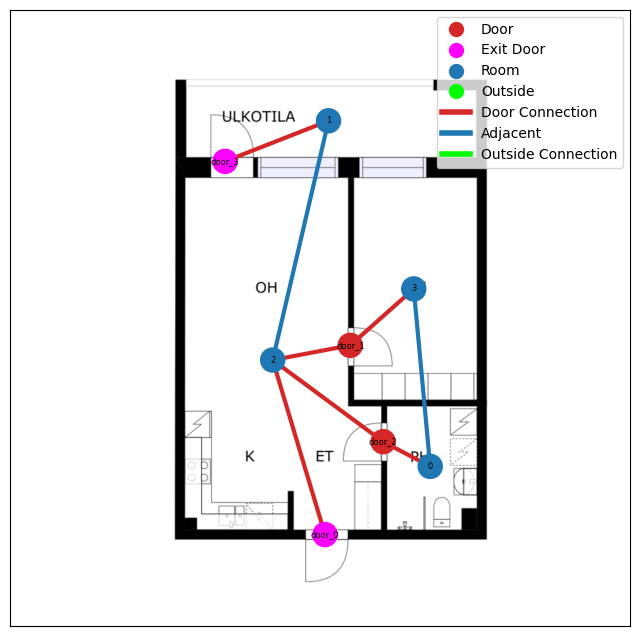

In [7]:
# Make a specific graph from the json data.
plan = 12581
G2Out = MakeGraph2(plan,True)
G2 = MakeGraph2(plan,False)

# Plot the Graph, with the floorplan.
GraphPlot(G2,plan)